# 04.5 · The Quiniela Strategy, Made Explicit

A **focused, self-contained deep dive into the betting (quiniela) strategy** — the decision layer
that turns one calibrated forecast into four pick sheets. Where notebook 04 surveys the whole
tournament, this one zooms in on *how the picks are made, why the profiles differ, and which one to
use*, and ends with conclusions you can act on.

**Core idea:** a probability is a *belief*; a pick is a *decision*. One forecast feeds four decision
policies — `safe`, `balanced`, `aggressive`, `contrarian` — that differ only in their utility (risk
appetite), never in the underlying probabilities.

**Prerequisite:** `export_quiniela_sheet.py` has been run (the four `outputs/picks/quiniela_*.csv`
exist). Section 5 also uses `outputs/predictions/scoreline_predictions.csv` if present.

In [1]:
import nb_style as nbs
nbs.apply_theme()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
from pathlib import Path

pd.set_option("display.width", 130)

OUT = Path("outputs")
CFG = Path("config")
PROFILES = ["safe", "balanced", "aggressive", "contrarian"]

# One forecast -> four decision policies. Load the four pick sheets + the strategy config.
sheets = {p: pd.read_csv(OUT / "picks" / f"quiniela_{p}.csv") for p in PROFILES}
strategy_cfg = yaml.safe_load((CFG / "strategy.yaml").read_text(encoding="utf-8"))

n_matches = len(next(iter(sheets.values())))
print(f"Loaded {len(PROFILES)} profiles x {n_matches} upcoming matches.\n")
for p in PROFILES:
    df = sheets[p]
    print(f"  {p:11s} picks={df['pick'].value_counts().to_dict()}  mean_conf={df['confidence'].mean():.3f}")

Loaded 4 profiles x 15 upcoming matches.

  safe        picks={'H': 15}  mean_conf=0.573
  balanced    picks={'H': 8, 'D': 7}  mean_conf=0.494
  aggressive  picks={'H': 9, 'A': 6}  mean_conf=0.481
  contrarian  picks={'A': 13, 'H': 2}  mean_conf=0.199


## 1. The rules of the game (the utility function)

Picks are **not** graded on accuracy — they are graded on **quiniela points**. Everything the
profiles do is an attempt to maximise *expected points*, and this point rule is the utility function
that makes "just pick the favourite" suboptimal.

Quiniela scoring rule (the utility the picks optimise):
  correct 1X2 ............ +1.0
  exact-score bonus ...... +2.0
  upset bonus ............ +1.0


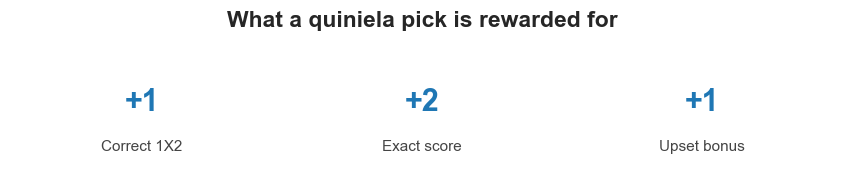

In [2]:
rule = strategy_cfg["scoring"]["quiniela_default"]
print("Quiniela scoring rule (the utility the picks optimise):")
print(f"  correct 1X2 ............ +{rule['correct_1x2']}")
print(f"  exact-score bonus ...... +{rule['exact_score_bonus']}")
print(f"  upset bonus ............ +{rule['upset_bonus']}")

nbs.kpi_header(
    [
        ("Correct 1X2", f"+{rule['correct_1x2']:.0f}"),
        ("Exact score", f"+{rule['exact_score_bonus']:.0f}"),
        ("Upset bonus", f"+{rule['upset_bonus']:.0f}"),
    ],
    title="What a quiniela pick is rewarded for",
)

## 2. The four profiles, in plain language

Each profile is the **same forecast** seen through a different risk appetite, controlled by three knobs:

- **`favorite_threshold`** — how confident the favourite must be before we simply back it.
- **`upset_tolerance`** — the minimum underdog probability needed to gamble on an upset / a fade.
- **`draw_bias`** — multiplies the draw probability before deciding: `<1` = draw-shy, `>1` = draw-hungry.

The table pairs the raw knobs with the actual decision rule each profile runs (translated from
`PickOptimizer.pick`).

In [3]:
prof = strategy_cfg["quiniela"]["risk_profiles"]
desc = {
    "safe": "Always the argmax favourite. Backs clear favourites only; draw-shy (draw_bias<1).",
    "balanced": "Argmax favourite, but falls back to a DRAW when no side clears favorite_threshold and the draw is live.",
    "aggressive": "Takes the UPSET only when the upset-window AND favorite-fragility signals both fire and the underdog clears upset_tolerance; otherwise grabs draw value or the favourite.",
    "contrarian": "Deliberately FADES the team with the higher public-bias proxy to maximise differentiation; draw-hungry (draw_bias>1).",
}
tbl = pd.DataFrame(prof).T[["favorite_threshold", "upset_tolerance", "draw_bias"]]
tbl["decision rule (plain language)"] = [desc[p] for p in tbl.index]
tbl

,favorite_threshold,upset_tolerance,draw_bias,decision rule (plain language)
safe,0.58,0.05,0.90,Always the argmax favourite. Backs clear favou...
balanced,0.50,0.10,1.00,"Argmax favourite, but falls back to a DRAW whe..."
aggressive,0.43,0.18,1.10,Takes the UPSET only when the upset-window AND...
contrarian,0.38,0.25,1.15,Deliberately FADES the team with the higher pu...


## 3. What each profile actually picks

The pick mix already tells the story: `safe` concentrates on favourites, `balanced` absorbs draws,
`aggressive` leans into more home/upset calls, and `contrarian` flips a large share of picks to fade
the crowd. (`H` = team_a win, `D` = draw, `A` = team_b win.)

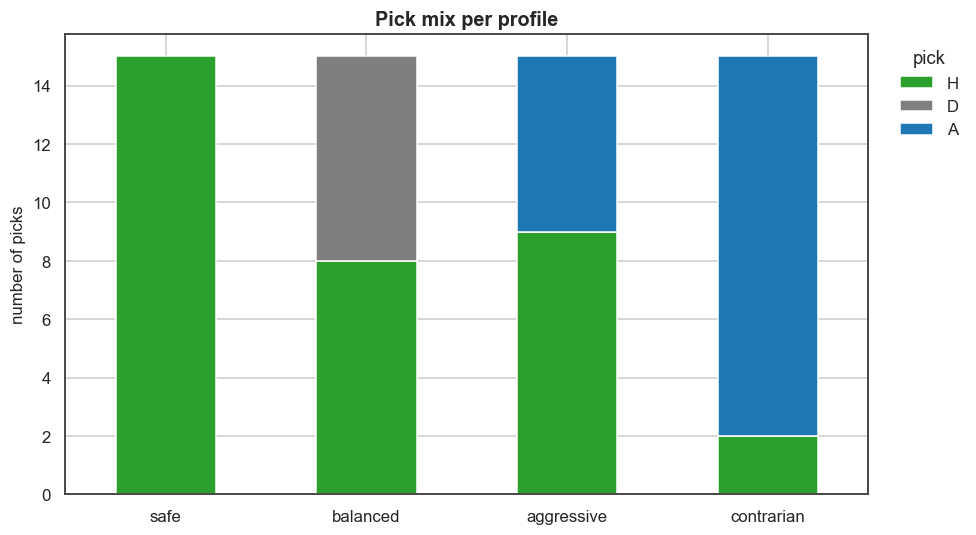

pick         H  D   A
safe        15  0   0
balanced     8  7   0
aggressive   9  0   6
contrarian   2  0  13

Mean confidence (probability mass on the picked outcome):
{'safe': 0.573, 'balanced': 0.494, 'aggressive': 0.481, 'contrarian': 0.199}


In [4]:
mix = (
    pd.DataFrame({p: sheets[p]["pick"].value_counts() for p in PROFILES})
    .reindex(["H", "D", "A"])
    .fillna(0)
    .astype(int)
    .T
)
ax = mix.plot(
    kind="bar", stacked=True, figsize=(9, 5),
    color={"H": "#2ca02c", "D": "#7f7f7f", "A": "#1f77b4"},
)
ax.set(title="Pick mix per profile", xlabel="", ylabel="number of picks")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="pick", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout(); plt.show()
print(mix.to_string())
print("\nMean confidence (probability mass on the picked outcome):")
print({p: round(float(sheets[p]['confidence'].mean()), 3) for p in PROFILES})

## 4. Anatomy of the decisions — *why* each pick was made

The optimizer records a `rationale` for every pick. Classifying it exposes the **mechanism** behind
each profile: how many picks are plain favourites, draw fallbacks, fragility-triggered upsets, or
deliberate contrarian fades. This is the single clearest view of how the strategies differ.

Why each profile made its picks (decision-type counts):

                             safe  balanced  aggressive  contrarian
rationale                                                          
draw (no clear favourite)       0         7           0           0
fade favourite (contrarian)     0         0           0          15
favourite (argmax)             15         8           9           0
upset (fragility fired)         0         0           6           0


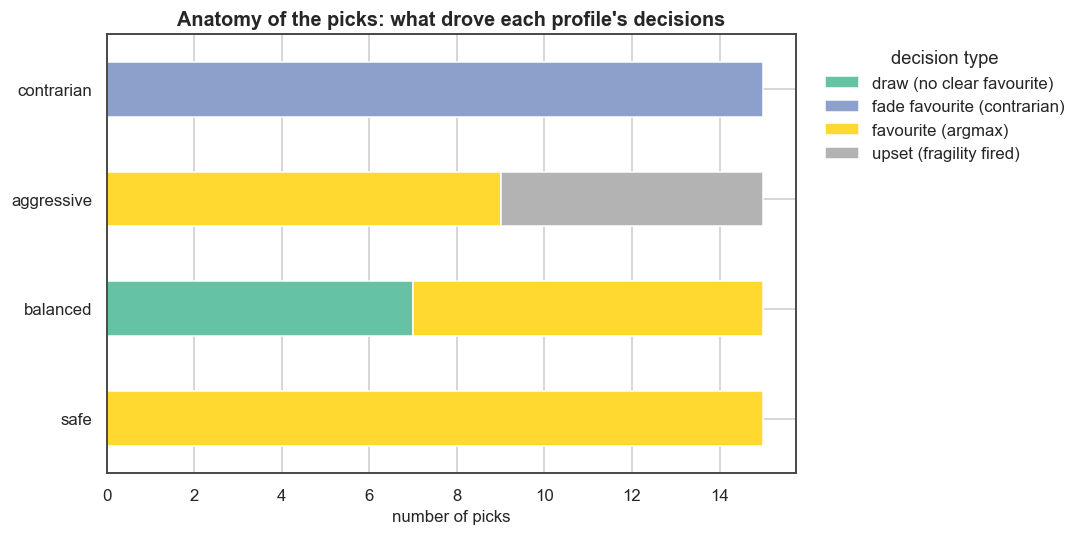

In [5]:
def classify(rationale: str) -> str:
    r = str(rationale)
    if "upset trigger" in r:
        return "upset (fragility fired)"
    if "draw fallback" in r:
        return "draw (no clear favourite)"
    if "draw value" in r:
        return "draw (value)"
    if "fade public bias" in r:
        return "fade favourite (contrarian)"
    return "favourite (argmax)"

if all("rationale" in sheets[p].columns for p in PROFILES):
    cat = pd.DataFrame(
        {p: sheets[p]["rationale"].map(classify).value_counts() for p in PROFILES}
    ).fillna(0).astype(int)
    print("Why each profile made its picks (decision-type counts):\n")
    print(cat.to_string())
    ax = cat.T.plot(kind="barh", stacked=True, figsize=(10, 5), colormap="Set2")
    ax.set(title="Anatomy of the picks: what drove each profile's decisions", xlabel="number of picks")
    ax.legend(title="decision type", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout(); plt.show()
else:
    print("rationale column missing — re-run export_quiniela_sheet.py (include_rationale: true).")

## 5. Expected value vs risk — the money chart

For each pick we compute expected points under the scoring rule:

- **+1** if the 1X2 is correct (probability `p_pick`),
- **+1** extra if that correct call is an *upset* (the pick is not the model's argmax),
- **+2** modal exact-score bonus, approximated as `exact_bonus × P(modal scoreline)` when the modal
  scoreline's outcome matches the pick (only when `scoreline_predictions.csv` is available).

`EV_total` sums expected points across the sheet; `risk` is the standard deviation of total points
(each pick treated as an independent Bernoulli on the 1X2+upset payoff). The rational default
maximises **points per unit of risk** — but the *right* choice depends on your position in the pool
(section 7).

   profile  EV_1x2_upset  exact_bonus_EV  EV_total  risk  EV_total_per_risk
      safe         8.382           1.303     9.685 1.855              5.220
  balanced         9.449           3.236    12.685 2.741              4.628
aggressive         9.022           1.303    10.325 2.589              3.988
contrarian         5.382           0.000     5.382 2.767              1.945


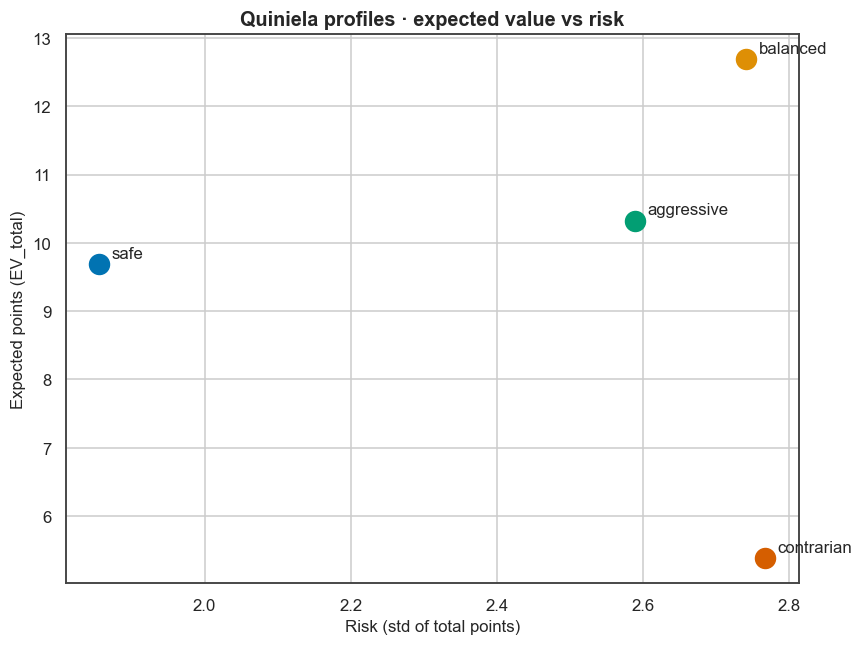

In [6]:
correct_pts = rule["correct_1x2"]
upset_pts = rule["upset_bonus"]
exact_pts = rule["exact_score_bonus"]

sl_path = OUT / "predictions" / "scoreline_predictions.csv"
sl = pd.read_csv(sl_path) if sl_path.exists() else None
if sl is not None:
    sl = sl.drop_duplicates(["team_a", "team_b"])

def outcome_of_score(s):
    try:
        a, b = (int(x) for x in str(s).split("-"))
    except Exception:
        return None
    return "H" if a > b else ("D" if a == b else "A")

def profile_stats(df):
    p = df[["p_home", "p_draw", "p_away"]].to_numpy()
    pick_idx = df["pick"].map({"H": 0, "D": 1, "A": 2}).to_numpy()
    p_pick = p[np.arange(len(df)), pick_idx]
    is_upset = pick_idx != p.argmax(axis=1)
    pts_if_right = correct_pts + np.where(is_upset, upset_pts, 0.0)
    ev = p_pick * pts_if_right                       # base EV (1X2 + upset)
    var = p_pick * (pts_if_right - ev) ** 2 + (1 - p_pick) * (0 - ev) ** 2

    exact_ev = np.zeros(len(df))
    if sl is not None:
        m = df.merge(sl[["team_a", "team_b", "top1_score", "top1_prob"]], on=["team_a", "team_b"], how="left")
        for i in range(len(df)):
            sc, pr = m["top1_score"].iloc[i], m["top1_prob"].iloc[i]
            if isinstance(sc, str) and outcome_of_score(sc) == df["pick"].iloc[i] and pd.notna(pr):
                exact_ev[i] = exact_pts * float(pr)
    return float(ev.sum()), float(np.sqrt(var.sum())), float(exact_ev.sum())

rows = []
for p in PROFILES:
    base_ev, risk, exact_ev = profile_stats(sheets[p])
    rows.append({
        "profile": p, "EV_1x2_upset": base_ev, "exact_bonus_EV": exact_ev,
        "EV_total": base_ev + exact_ev, "risk": risk,
    })
stats = pd.DataFrame(rows)
stats["EV_total_per_risk"] = stats["EV_total"] / stats["risk"]
print(stats.round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 6))
for _, r in stats.iterrows():
    ax.scatter(r["risk"], r["EV_total"], s=170)
    ax.annotate(r["profile"], (r["risk"], r["EV_total"]), xytext=(8, 4), textcoords="offset points", fontsize=11)
ax.set(title="Quiniela profiles · expected value vs risk", xlabel="Risk (std of total points)", ylabel="Expected points (EV_total)")
plt.tight_layout(); plt.show()

## 6. Where the profiles disagree (the matches that matter)

If every profile agreed, the risk tiers would be cosmetic. The matches where picks diverge are
exactly where strategy has real value — sorted here by how close the match is (small probability
spread = genuine coin-flip = most strategic freedom).

In [7]:
base = sheets["balanced"][["team_a", "team_b", "p_home", "p_draw", "p_away"]].copy()
for p in PROFILES:
    base[f"pick_{p}"] = sheets[p]["pick"].values

probs = base[["p_home", "p_draw", "p_away"]]
base["spread"] = probs.max(axis=1) - probs.min(axis=1)
pick_cols = [f"pick_{p}" for p in PROFILES]
mask = base[pick_cols].nunique(axis=1) > 1
disagree = base[mask].sort_values("spread")

print(f"Profiles disagree on {len(disagree)}/{len(base)} matches.\n")
print(disagree[["team_a", "team_b", "p_home", "p_draw", "p_away", *pick_cols]].head(12).round(3).to_string(index=False))

Profiles disagree on 15/15 matches.

       team_a             team_b  p_home  p_draw  p_away pick_safe pick_balanced pick_aggressive pick_contrarian
       Mexico            Ecuador   0.364   0.327   0.309         H             D               H               A
  Ivory Coast             Norway   0.362   0.291   0.347         H             D               A               H
  Switzerland            Algeria   0.415   0.277   0.308         H             D               A               A
       Brazil              Japan   0.447   0.279   0.274         H             D               A               A
    Australia              Egypt   0.462   0.283   0.255         H             D               A               H
  Netherlands            Morocco   0.474   0.288   0.238         H             D               A               A
      Belgium            Senegal   0.487   0.293   0.221         H             D               A               A
     Portugal            Croatia   0.595   0.242   0.163   

## 7. Which profile should *you* use?

This is pari-mutuel game theory, not accuracy maximisation: your payoff depends on what everyone
else picked. Choose your risk appetite from your **position in the pool**:

| Your situation | Use | Why |
|---|---|---|
| Protecting a lead / want low variance | **safe** | Backs only clear favourites; minimises blow-ups. |
| Maximising expected points, no strong position | **balanced** | Solid EV-per-risk default; takes draws when they're live. |
| Mid-pack, need to climb in a medium pool | **aggressive** | Disciplined upsets when fragility signals fire — upside without recklessness. |
| Behind / large pool / single big prize | **contrarian** | Trades accuracy for *differentiation*; a lonely correct call pays the most. |

**Rule of thumb:** the larger the pool and the more top-heavy the prize, the more variance (and
contrarian differentiation) is worth — because being right *with the crowd* wins you almost nothing.

In [8]:
best_ev = stats.loc[stats["EV_total"].idxmax(), "profile"]
best_ratio = stats.loc[stats["EV_total_per_risk"].idxmax(), "profile"]
safest = stats.loc[stats["risk"].idxmin(), "profile"]

print("EXECUTIVE SUMMARY (from this sheet)")
print(f"  Highest expected points ........ {best_ev}")
print(f"  Best points-per-unit-of-risk ... {best_ratio}")
print(f"  Lowest variance (safest) ....... {safest}")
print(f"  Matches with strategic disagreement: {len(disagree)}/{len(base)}")

EXECUTIVE SUMMARY (from this sheet)
  Highest expected points ........ balanced
  Best points-per-unit-of-risk ... safe
  Lowest variance (safest) ....... safe
  Matches with strategic disagreement: 15/15


## 8. Conclusions

- **One forecast, four decisions.** The probabilities are identical across profiles; only the
  utility-shaped decision rule changes. That keeps the model honest and the strategy cheap to tune.
- **`argmax(p)` is optimal only under 0/1 utility.** The quiniela's upset (+1) and exact-score (+2)
  bonuses are exactly why the aggressive/contrarian profiles deviate from the favourite.
- **EV vs risk is a real trade-off** (section 5): choose by *points-per-risk* if you have no
  position, and by *variance appetite* if you do.
- **Strategy only matters where profiles disagree** (section 6) — focus your attention there.
- **Differentiated accuracy beats raw accuracy** in a pool: the contrarian fade is rational
  precisely because a correct-but-crowded pick pays little.

**How to draw your own conclusion:** read section 5 for the EV/risk numbers, decide your position in
the pool from section 7, then take that profile's sheet from `outputs/picks/` — paying special
attention to the disagreement matches in section 6, where your choice actually changes the bet.

## 9. The decision table — every remaining match, all four picks

The consolidated view for actually filling a quiniela: one row per remaining match, the outcome each
profile would pick, and **the model's probability for that picked outcome** (a low % flags a
deliberate contrarian fade, not a confident call). The last column is the most-likely scoreline
(home-away). Matches where the four columns differ are where your risk profile actually changes the bet.

In [9]:
import ast

PICK_PROB = {"H": "p_home", "D": "p_draw", "A": "p_away"}

def _label(row, pick):
    if pick == "H":
        return row["team_a"]
    if pick == "A":
        return row["team_b"]
    return "Draw"

def _fmt_score(s):
    try:
        a, b = ast.literal_eval(str(s))
        return f"{int(a)}-{int(b)}"
    except Exception:
        return str(s)

base_sheet = sheets["balanced"]
records = []
for i in range(len(base_sheet)):
    r = base_sheet.iloc[i]
    rec = {"date": str(r["date"])[:10], "match": f'{r["team_a"]} vs {r["team_b"]}'}
    for p in PROFILES:
        rp = sheets[p].iloc[i]
        pk = rp["pick"]
        rec[p] = f"{_label(rp, pk)} ({rp[PICK_PROB[pk]] * 100:.0f}%)"
    rec["scoreline"] = _fmt_score(r.get("scoreline", ""))
    records.append(rec)

decision_table = pd.DataFrame(records).sort_values("date").reset_index(drop=True)
# To export:  decision_table.to_csv(OUT / "picks" / "decision_table_remaining.csv", index=False)
decision_table

,date,match,safe,balanced,aggressive,contrarian,scoreline
0,2026-06-29,Germany vs Paraguay,Germany (65%),Germany (65%),Germany (65%),Paraguay (12%),1-1
1,2026-06-29,Netherlands vs Morocco,Netherlands (47%),Draw (29%),Morocco (24%),Morocco (24%),1-1
2,2026-06-29,Brazil vs Japan,Brazil (45%),Draw (28%),Japan (27%),Japan (27%),1-1
3,2026-06-30,Ivory Coast vs Norway,Ivory Coast (36%),Draw (29%),Norway (35%),Ivory Coast (36%),1-1
4,2026-06-30,Mexico vs Ecuador,Mexico (36%),Draw (33%),Mexico (36%),Ecuador (31%),0-0
5,2026-06-30,France vs Sweden,France (70%),France (70%),France (70%),Sweden (11%),2-1
6,2026-07-01,England vs Congo DR,England (74%),England (74%),England (74%),Congo DR (9%),2-0
7,2026-07-01,United States vs Bosnia-Herzegovina,United States (67%),United States (67%),United States (67%),Bosnia-Herzegovina (12%),1-1
8,2026-07-01,Belgium vs Senegal,Belgium (49%),Draw (29%),Senegal (22%),Senegal (22%),1-1
9,2026-07-02,Spain vs Austria,Spain (64%),Spain (64%),Spain (64%),Austria (13%),1-1
